### 1. Instalación de dependencias.

In [1]:
import os
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from google.colab import drive
warnings.filterwarnings("ignore")

In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Definición de rutas del proyecto
PROJECT_PATH = "/content/drive/MyDrive/DataJAM_Bogota_2026/"
RAW_DATA_PATH = os.path.join(PROJECT_PATH, "data/raw/")
PROCESSED_DATA_PATH = os.path.join(PROJECT_PATH, "data/processed/")
OUTPUTS_FIG_PATH = os.path.join(PROJECT_PATH, "outputs/figures/")
OUTPUTS_TABLE_PATH = os.path.join(PROJECT_PATH, "outputs/tables/")

print(f"Inicialización del Entorno 002 completada.\n")

Inicialización del Entorno 002 completada.



### 2. Carga de artefactos procesados.

In [4]:
# 2.1 Conjunto de datos espacial maestro (Agregado a nivel de localidad/UPL)
master_gdf = gpd.read_file(
    os.path.join(
        PROCESSED_DATA_PATH, "master_mental_health_bogota_2025.geojson")
)

# 2.2 Microdatos depurados de suicidios consumados (Fila por evento)
suicide_events_df = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "suicide_events_clean.csv"),
    encoding="utf-8-sig",
    low_memory=False,
)

# 2.3 Microdatos depurados de la Encuesta de Percepción 2025 (Fila por persona encuestada)
perception_microdata_df = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "perception_survey_clean.csv"),
    encoding="utf-8-sig",
    low_memory=False,
)

print(f"Capa espacial maestra cargada: {len(master_gdf)} entidades territoriales.")
print(f"Registros de microdatos listos para el modelado econométrico.")

Capa espacial maestra cargada: 20 entidades territoriales.
Registros de microdatos listos para el modelado econométrico.


### 3. Cálculo de indicadores epidemiológicos (Periodo 2023-2025).

In [5]:
suicides_window_df = suicide_events_df[
    suicide_events_df["year"].isin([2023, 2024, 2025])
].copy()

# 3.1. Estandarizar la columna de localidad (Mayúsculas y sin tildes)
suicides_window_df["LOCALIDAD_DEL_HECHO"] = (
    suicides_window_df["LOCALIDAD_DEL_HECHO"]
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.strip()
)

suicides_window_df["SEXO_DE_LA_VICTIMA"] = (
    suicides_window_df["SEXO_DE_LA_VICTIMA"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# 3.2. Agrupar conteo de suicidios por localidad y sexo
suicide_summary_df = (
    suicides_window_df.groupby(["LOCALIDAD_DEL_HECHO", "SEXO_DE_LA_VICTIMA"])
    .size()
    .unstack(fill_value=0)
)
suicide_summary_df.columns.name = None

# 3.3. Lista de localidades estandarizada
all_localities = [
    "ANTONIO NARINO", "BARRIOS UNIDOS", "BOSA", "CHAPINERO",
    "CIUDAD BOLIVAR", "ENGATIVA", "FONTIBON", "KENNEDY",
    "LA CANDELARIA", "LOS MARTIRES", "PUENTE ARANDA",
    "RAFAEL URIBE URIBE", "SAN CRISTOBAL", "SANTA FE",
    "SUBA", "SUMAPAZ", "TEUSAQUILLO", "TUNJUELITO",
    "USAQUEN", "USME"
]

# Reindex añade Sumapaz y rellena sus valores faltantes con 0
suicide_summary_df = suicide_summary_df.reindex(all_localities, fill_value=0).reset_index()
suicide_summary_df = suicide_summary_df.rename(columns={"index": "LOCALIDAD_DEL_HECHO"})

# 3.4. Calcular el total consolidado
hombre_count = suicide_summary_df["hombre"] if "hombre" in suicide_summary_df.columns else 0
mujer_count = suicide_summary_df["mujer"] if "mujer" in suicide_summary_df.columns else 0

suicide_summary_df["total_suicides_2023_2025"] = hombre_count + mujer_count

# 3.5. Exportar la tabla resumen limpia
suicide_summary_df.to_csv(
    os.path.join(OUTPUTS_TABLE_PATH, "suicide_summary_by_locality_2023_2025.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("Indicadores epidemiológicos tabulados correctamente para 2023-2025 (n=20).")

Indicadores epidemiológicos tabulados correctamente para 2023-2025 (n=20).


### 4. Modelo econométrico: Determinantes estructurales de salud deficiente

In [11]:
# 4.1 Definición de la variable dependiente binaria
perception_microdata_df["poor_health"] = perception_microdata_df[
    "IND_SALUD_101"
].astype(int)

# 4.2 Selección y filtrado de variables explicativas clave
model_vars = ["poor_health", "A3", "A4", "A5", "A6X2"]

# Crear dataframe filtrado sin valores nulos ni códigos de No Responde (>90)
df_logit = perception_microdata_df[model_vars].copy()
df_logit = df_logit.dropna()

# 4.3 Especificación del modelo (Omitimos A5 como categoría de referencia)
# Al omitir A5, rompemos la multicolinealidad perfecta y A5 se vuelve la base de comparación.
logit_formula = "poor_health ~ A3 + A4 + C(A6X2, Treatment(reference=0))"

logit_model = smf.logit(formula=logit_formula, data=df_logit).fit(
    method="newton", maxiter=100
)
print(logit_model.summary())

# 4.5 Cálculo de los Efectos Marginales Promedio (AME)
try:
    ame_summary = logit_model.get_margeff(at="overall")
    print("\n=== EFECTOS MARGINALES PROMEDIO (AME) ===")
    print(ame_summary.summary())
except Exception as e:
    print(f"\nNota AME: {e}")

# 4.6 Diccionario de etiquetas para categorías de A6X2 (parentesco con jefe de hogar)
a6x2_labels = {
    0: "Jefe del hogar (referencia)",
    1: "Cónyuge",
    2: "Hija(o)",
    3: "Nuera/yerno",
    4: "Nieta(o)",
    5: "Padre/madre",
    6: "Suegra(o)",
    7: "Hermana(o)",
    8: "Cuñada(o)",
    9: "Pariente",
    10: "No pariente",
}

def clean_variable_name(raw_name):
    """Convierte nombres técnicos de statsmodels en etiquetas legibles."""
    if raw_name == "Intercept":
        return "Intercepto"
    if raw_name == "A3":
        return "A3 — N° personas en el hogar"
    if raw_name == "A4":
        return "A4 — N° menores de 18 años en el hogar"
    if "A6X2" in raw_name:
        code = int(float(raw_name.split("T.")[1].replace("]", "")))
        return f"A6x2 — {a6x2_labels[code]}"
    return raw_name

# 4.7 Tabla de coeficientes con nombres legibles
model_results_df = pd.DataFrame(
    {
        "Coeficiente": logit_model.params,
        "Error_Estandard": logit_model.bse,
        "P_Value": logit_model.pvalues,
        "Odds_Ratio": np.exp(logit_model.params),
    }
)
model_results_df = model_results_df.reset_index().rename(columns={"index": "Variable_raw"})
model_results_df["Variable"] = model_results_df["Variable_raw"].apply(clean_variable_name)
model_results_df = model_results_df.drop(columns=["Variable_raw"])

model_results_df.to_csv(
    f"{PROCESSED_DATA_PATH}model_coefficients.csv",
    index=False,
    encoding="utf-8-sig",
)

# 4.8 Tabla de efectos marginales (AME) con nombres legibles
ame_df = ame_summary.summary_frame().reset_index()
ame_df.columns = ["Variable_raw", "Efecto_Marginal", "Error_Estandar", "Z", "P_Value", "IC_2.5", "IC_97.5"]
ame_df["Variable"] = ame_df["Variable_raw"].apply(clean_variable_name)
ame_df = ame_df.drop(columns=["Variable_raw"])

ame_df.to_csv(
    f"{PROCESSED_DATA_PATH}ame_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

# 4.9 Estadísticos de ajuste del modelo
model_fit_stats = pd.DataFrame([{
    "N_obs": int(logit_model.nobs),
    "Pseudo_R2": logit_model.prsquared,
    "Log_Likelihood": logit_model.llf,
    "LLR_pvalue": logit_model.llr_pvalue,
}])
model_fit_stats.to_csv(
    f"{PROCESSED_DATA_PATH}model_fit_stats.csv",
    index=False,
    encoding="utf-8-sig",
)

# 4.10 Mantener también el export original a outputs/tables (para el repositorio técnico)
model_results_df.to_csv(
    os.path.join(OUTPUTS_TABLE_PATH, "logit_model_health_determinants.csv"),
    index=False,
    encoding="utf-8-sig",
)

print(f"\nResultados econométricos exportados exitosamente a:")
print(f"  - {PROCESSED_DATA_PATH} (model_coefficients.csv, ame_summary.csv, model_fit_stats.csv)")
print(f"  - {OUTPUTS_TABLE_PATH} (logit_model_health_determinants.csv)")

Optimization terminated successfully.
         Current function value: 0.603023
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            poor_health   No. Observations:                13082
Model:                          Logit   Df Residuals:                    13069
Method:                           MLE   Df Model:                           12
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                 0.01162
Time:                        06:50:48   Log-Likelihood:                -7888.8
converged:                       True   LL-Null:                       -7981.5
Covariance Type:            nonrobust   LLR p-value:                 3.246e-33
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   0.8003

In [12]:
perception_microdata_df["A6X2"].value_counts()

,count
A6X2,
0.0,8384
1.0,2399
2.0,1343
5.0,346
7.0,247
9.0,117
4.0,85
10.0,62
3.0,49


### 5. Generación de cartigrafía temática (Infraestructura Verde Bogotá)

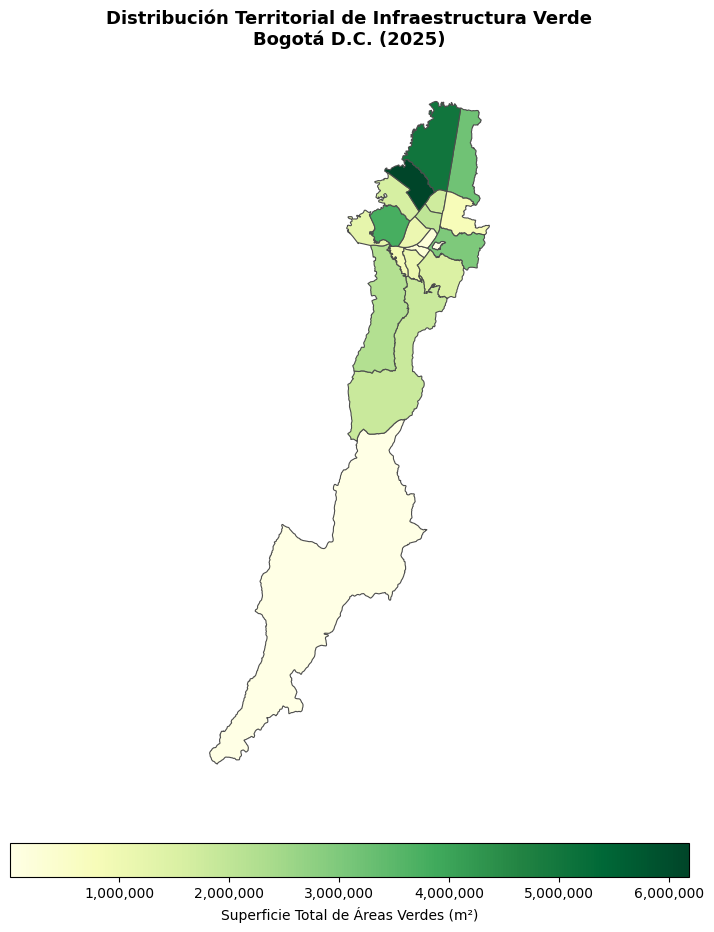

In [13]:
# 5.1 Renderizar mapa coroplético de Infraestructura Verde (Toda Bogotá, n=20)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

map_gdf = master_gdf.copy()

# [NUEVO] Proyección a MAGNA-SIRGAS Origen Nacional (EPSG:9377) para evitar distorsión visual
if map_gdf.crs and map_gdf.crs.to_epsg() != 9377:
    map_gdf = map_gdf.to_crs(epsg=9377)

map_gdf.plot(
    column="total_green_area_sqm",
    cmap="YlGn", # [AJUSTE] Paleta más intuitiva para temática "verde"
    linewidth=0.8,
    ax=ax,
    edgecolor="0.3",
    legend=True,
    legend_kwds={
        "label": "Superficie Total de Áreas Verdes (m²)",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.05,
        "format": "{x:,.0f}", # [AJUSTE] Separadores de miles en la barra de colores
    },
)

# Título ajustado para abarcar toda la ciudad
ax.set_title(
    "Distribución Territorial de Infraestructura Verde\nBogotá D.C. (2025)",
    fontsize=13,
    fontweight="bold",
)
ax.set_axis_off()
plt.tight_layout()

# 5.2 Exportar y mostrar
output_map_path = os.path.join(OUTPUTS_FIG_PATH, "map_green_infrastructure_bogota.png")
plt.savefig(output_map_path, dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

In [14]:
master_gdf[master_gdf["total_green_area_sqm"].isna()][["locality_clean", "total_green_area_sqm"]]

,locality_clean,total_green_area_sqm


### 6. Análisis Demográfico: Brecha de Género en Eventos de Suicidio (2023-2025)

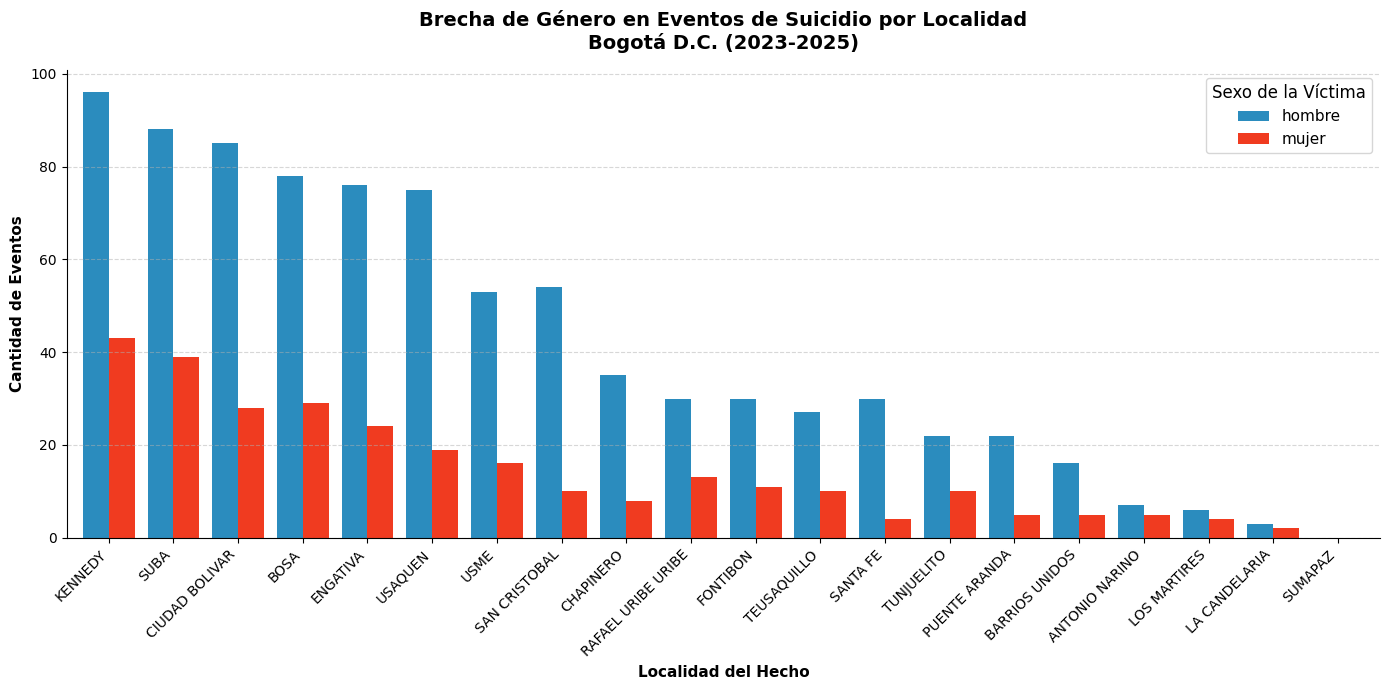

In [15]:
# 6.1 Ordenar el dataframe de mayor a menor impacto y FORZAR el nuevo índice
plot_df = suicide_summary_df.sort_values(by="total_suicides_2023_2025", ascending=False).reset_index(drop=True)

# 6.2 Configurar el lienzo del gráfico
fig, ax = plt.subplots(figsize=(14, 7))

# Crear barras agrupadas (Side-by-Side)
plot_df.plot(
    x="LOCALIDAD_DEL_HECHO",
    y=["hombre", "mujer"],
    kind="bar",
    color=["#2b8cbe", "#f03b20"], # Azul para Hombres, Rojo/Coral para Mujeres
    ax=ax,
    width=0.8
)

# 6.3 Limpieza y ajustes estéticos (Estilo minimalista)
ax.set_title(
    "Brecha de Género en Eventos de Suicidio por Localidad\nBogotá D.C. (2023-2025)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Localidad del Hecho", fontsize=11, fontweight="bold")
ax.set_ylabel("Cantidad de Eventos", fontsize=11, fontweight="bold")
ax.legend(title="Sexo de la Víctima", fontsize=11, title_fontsize=12)

# Rotar las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=45, ha="right")

# Líneas de cuadrícula solo horizontales para guiar el ojo
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Remover las líneas superior y derecha de la caja del gráfico (Descluttering)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 6.4 Exportar a tu carpeta de figuras y mostrar en pantalla
output_bar_path = os.path.join(OUTPUTS_FIG_PATH, "bar_gender_gap_suicides.png")
plt.savefig(output_bar_path, dpi=300, bbox_inches="tight")
plt.show()

### 7. Efecto de la "Carga de Cuidado" en Eventos de Suicidio (2023-2025)

In [16]:
# Agrupar categorías con muestra insuficiente (5, 6 y 7 menores a cargo -> "5+")
perception_microdata_df["A4_agrupada"] = perception_microdata_df["A4"].apply(
    lambda x: "5+" if x >= 5 else str(int(x))
)

# Verificación rápida de los nuevos tamaños de grupo
perception_microdata_df.groupby("A4_agrupada")["poor_health"].agg(n="count", proporcion="mean")

,n,proporcion
A4_agrupada,,
0,8275,0.661511
1,2968,0.785040
2,1464,0.767760
3,311,0.662379
4,51,0.529412
5+,13,0.615385


In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

group_sizes = perception_microdata_df.groupby("A4_agrupada")["poor_health"].count()
order = ["0", "1", "2", "3", "4", "5+"]

sns.barplot(
    data=perception_microdata_df,
    x="A4_agrupada",
    y="poor_health",
    order=order,
    estimator=lambda x: sum(x) / len(x) * 100,
    errorbar=("ci", 95),
    palette="mako",
    capsize=0.1,
    err_kws={"linewidth": 1.5, "color": "#333333"},
    ax=ax,
)

for i, cat in enumerate(order):
    n = group_sizes.get(cat, 0)
    ax.text(i, 3, f"n={n}", ha="center", va="bottom", fontsize=8, color="white", fontweight="bold")

ax.set_title(
    "Efecto del Trabajo de Cuidado en la Salud Percibida",
    fontsize=14, pad=15, fontweight="bold",
)
ax.set_xlabel("Cantidad de Menores a Cargo (Variable A4)", fontsize=11, labelpad=10)
ax.set_ylabel("Proporción con Salud Deficiente (%)", fontsize=11, labelpad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 8. Contraste Urbano-Epidemiológico (Áreas Verdes vs. Suicidios)

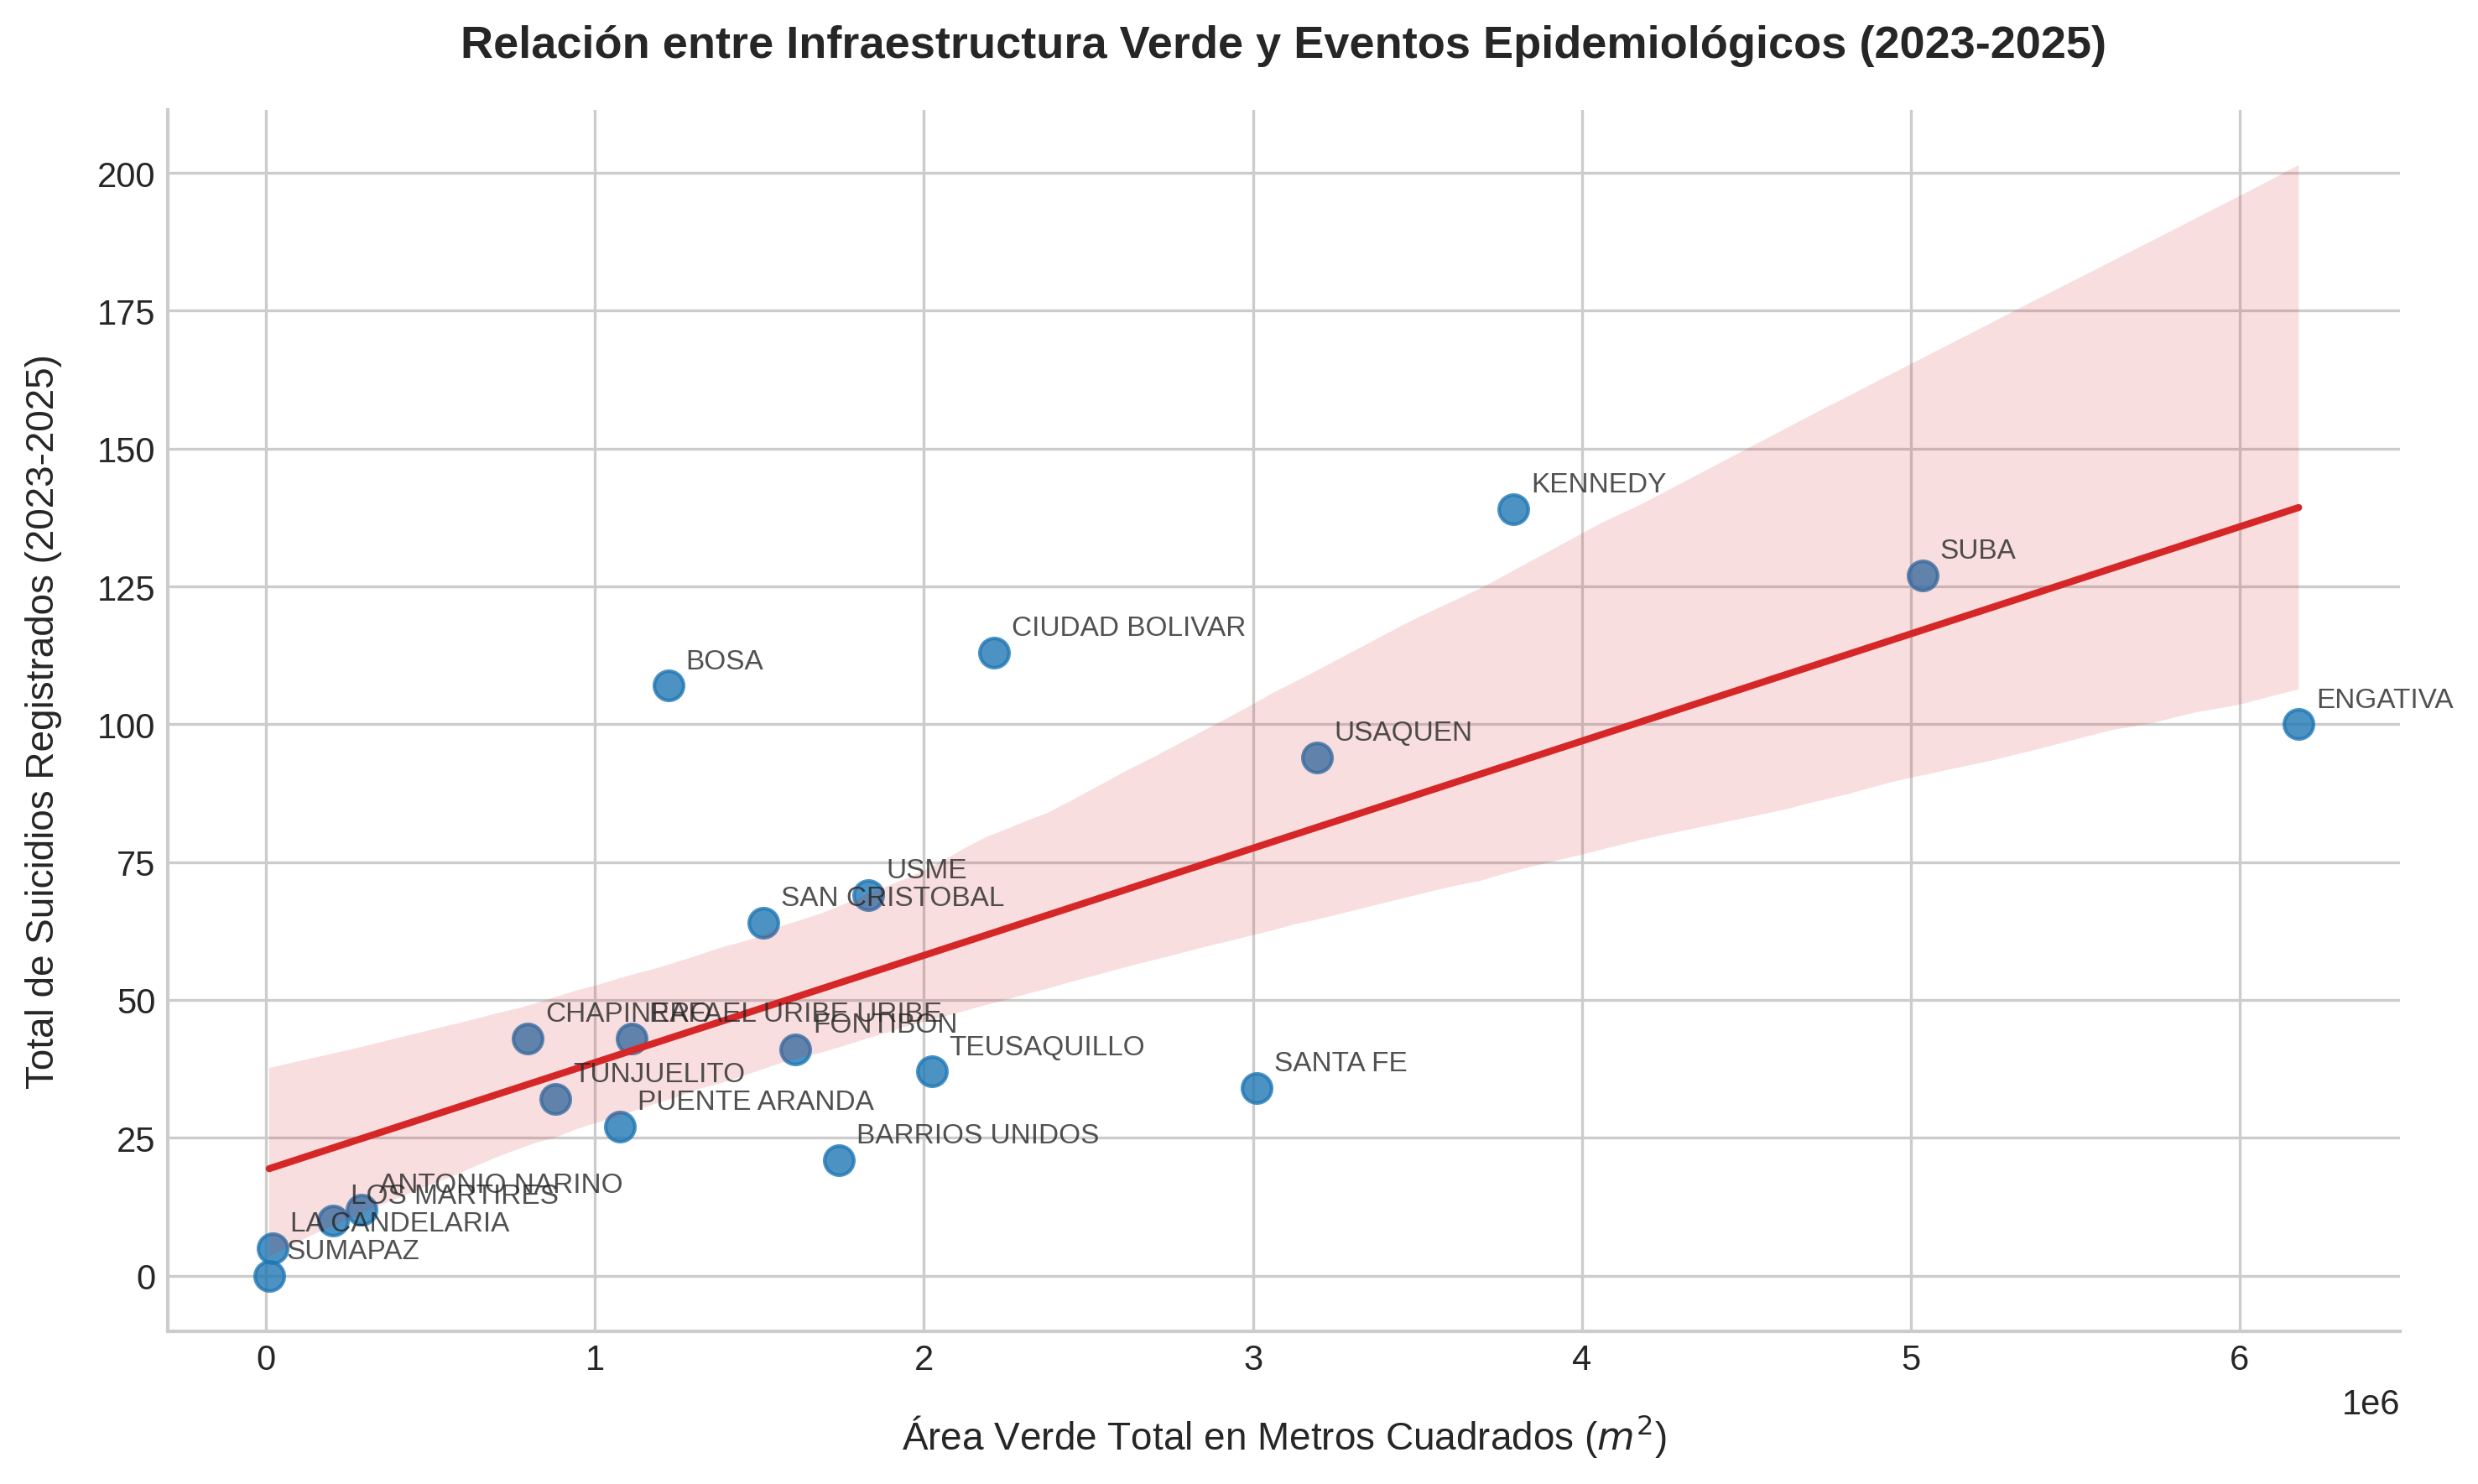

In [ ]:
# Unir los DataFrames usando la llave limpia
df_grafica = master_gdf.merge(
    suicide_summary_df,
    left_on='locality_clean',
    right_on='LOCALIDAD_DEL_HECHO',
    how='inner'
)

# Configurar y crear la figura
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

sns.regplot(
    data=df_grafica,
    x="total_green_area_sqm",
    y="total_suicides_2023_2025",
    scatter_kws={
        "s": 70,
        "color": "#1f77b4",
        "alpha": 0.8,
    },
    line_kws={"color": "#d62728", "linewidth": 2},
    ax=ax,
)

# Etiquetar cada punto usando el nombre original (locality_clean)
for i in range(len(df_grafica)):
    ax.annotate(
        df_grafica["locality_clean"].iloc[i],
        (
            df_grafica["total_green_area_sqm"].iloc[i],
            df_grafica["total_suicides_2023_2025"].iloc[i],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.8,
    )

ax.set_title(
    "Relación entre Infraestructura Verde y Eventos Epidemiológicos (2023-2025)",
    fontsize=13,
    pad=15,
    fontweight="bold",)
ax.set_xlabel(
    "Área Verde Total en Metros Cuadrados ($m^2$)", fontsize=11, labelpad=10)
ax.set_ylabel(
    "Total de Suicidios Registrados (2023-2025)", fontsize=11, labelpad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

plt.show()

In [ ]:
# Exportar el resumen de suicidios por localidad (para el bar chart de género)
suicide_summary_df.to_csv(f"{PROCESSED_DATA_PATH}suicide_summary.csv", index=False)

# Exportar el resumen del modelo logit (para el expander de estadísticas)
with open(f"{PROCESSED_DATA_PATH}logit_summary.txt", "w") as f:
    f.write(logit_model.summary().as_text())

# Exportar el dataframe agrupado para el gráfico de menores a cargo
group_sizes.to_csv(f"{PROCESSED_DATA_PATH}a4_group_sizes.csv")

perception_microdata_df[["A4_agrupada", "poor_health"]].to_csv(
    f"{PROCESSED_DATA_PATH}perception_a4.csv", index=False
)